In [3]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec, FastText
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv('twitter_training.csv', header=None, names=['ID', 'Game', 'Sentiment', 'Text'])
df.head()

,ID,Game,Sentiment,Text
0,target,word,label,tweet
1,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
2,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
3,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
4,2401,Borderlands,Positive,im coming on borderlands and i will murder you...


In [5]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # Explicitly download the missing resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# Load the dataset
df = pd.read_csv('twitter_training.csv', header=None, names=['ID', 'Game', 'Sentiment', 'Text'])

In [7]:
# Handle missing values in the 'Text' column
df = df.dropna(subset=['Text'])  # Option 1: Drop rows with missing values
# df['Text'] = df['Text'].fillna('')  # Option 2: Fill missing values with an empty string

In [8]:
# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [9]:
# Apply preprocessing to the dataset
df['Processed_Text'] = df['Text'].apply(preprocess_text)
df.head()

,ID,Game,Sentiment,Text,Processed_Text
0,target,word,label,tweet,[tweet]
1,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,"[im, getting, borderlands, murder]"
2,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,"[coming, borders, kill]"
3,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,"[im, getting, borderlands, kill]"
4,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,"[im, coming, borderlands, murder]"


In [10]:
# Convert processed text back to strings for CountVectorizer
df['Processed_Text_Str'] = df['Processed_Text'].apply(lambda x: ' '.join(x))

# Create BoW representation
vectorizer = CountVectorizer(max_features=1000)  # Limit to top 1000 words
bow_matrix = vectorizer.fit_transform(df['Processed_Text_Str'])

# Convert to DataFrame for visualization
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
bow_df.head()

,able,absolute,absolutely,access,account,accounts,achievement,action,activision,actual,...,years,yes,yesterday,yet,yo,youre,youtu,youtube,youtubecom,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Sparsity of BoW Matrix: 0.9938


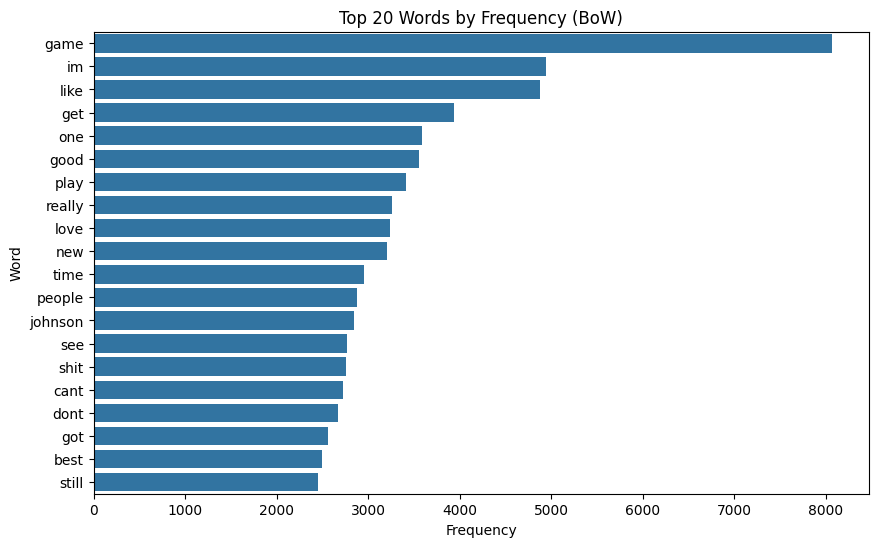

In [11]:
# Check sparsity
sparsity = 1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]))
print(f"Sparsity of BoW Matrix: {sparsity:.4f}")

# Visualize word frequencies
word_frequencies = bow_matrix.sum(axis=0).A1
word_freq_df = pd.DataFrame({'Word': vectorizer.get_feature_names_out(), 'Frequency': word_frequencies})
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False).head(20)

# Plot top 20 words
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=word_freq_df)
plt.title('Top 20 Words by Frequency (BoW)')
plt.show()

In [12]:
# Create TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Limit to top 1000 words
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Processed_Text_Str'])

# Convert to DataFrame for visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.head()

,able,absolute,absolutely,access,account,accounts,achievement,action,activision,actual,...,years,yes,yesterday,yet,yo,youre,youtu,youtube,youtubecom,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


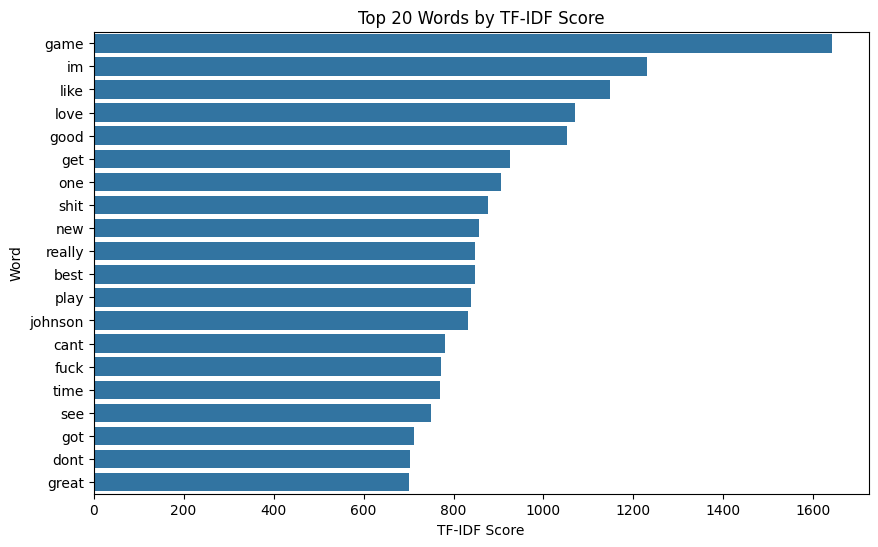

In [13]:
# Visualize top TF-IDF scores
tfidf_scores = tfidf_matrix.sum(axis=0).A1
tfidf_score_df = pd.DataFrame({'Word': tfidf_vectorizer.get_feature_names_out(), 'TF-IDF Score': tfidf_scores})
tfidf_score_df = tfidf_score_df.sort_values(by='TF-IDF Score', ascending=False).head(20)

# Plot top 20 words by TF-IDF score
plt.figure(figsize=(10, 6))
sns.barplot(x='TF-IDF Score', y='Word', data=tfidf_score_df)
plt.title('Top 20 Words by TF-IDF Score')
plt.show()

In [14]:
# Train Word2Vec model
word2vec_model = Word2Vec(sentences=df['Processed_Text'], vector_size=100, window=5, min_count=1, workers=4)

# Save the model
word2vec_model.save("word2vec.model")

Vector for 'game': [ 0.5900575  -0.34855458 -1.64348     0.6705458  -0.423192   -0.2663752
  1.620592    1.3033044  -2.378607    0.6590849  -0.76852316 -0.9703982
 -1.1692821  -0.4956507  -0.9413236  -0.5491503   0.38161895 -0.88490206
 -2.5775394  -0.6292607   1.8868402   1.103978    0.8884114   0.30353037
 -0.2738654   0.22837487  0.5057827   1.4642241  -1.4036082  -0.57446915
  0.3753455  -0.88470656  0.2885567  -0.97941697 -0.79666066 -0.7957407
 -0.67991686 -0.29538992  0.20397769  0.03561752 -0.7771919  -0.05567468
  0.2535596   1.2547739  -0.04082699  0.24237725 -1.0315676  -0.25343058
  0.03659445  0.28665528 -0.63891155 -0.92478716 -1.483474   -0.82043535
  0.9964363  -1.1794202   1.287825   -1.972559    0.03655557  0.26887986
 -1.1021516  -0.877041    0.44219846 -1.0289375  -1.9342024   1.1993146
 -0.7376087   0.84008735  0.30589867 -0.45653716 -0.79373825  1.0097725
  0.7392016  -1.4728717  -0.727207    1.4924592   1.1026405   0.01564448
 -0.53192014 -1.1082996  -0.30971703 

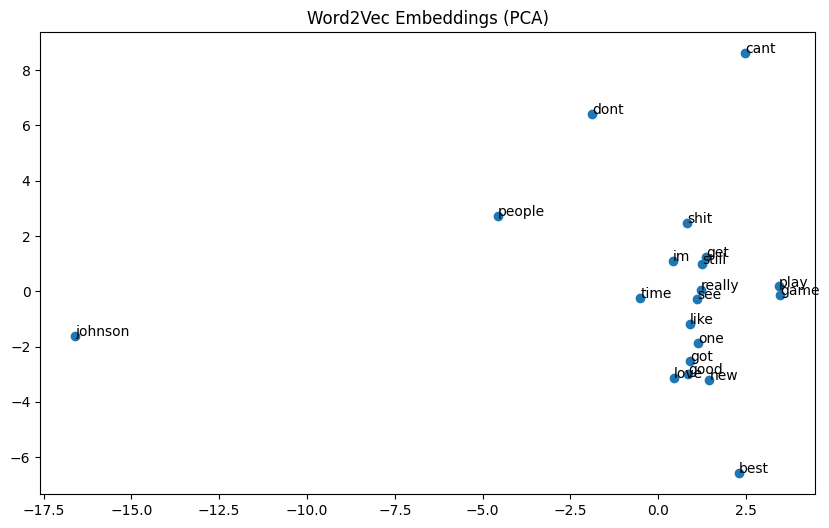

In [15]:
# Get word vectors
word_vectors = word2vec_model.wv

# Example: Get vector for a specific word
vector = word_vectors['game']
print(f"Vector for 'game': {vector}")

# Visualize word embeddings (e.g., using PCA)
from sklearn.decomposition import PCA

# Get vectors for top 20 words
words = word_freq_df['Word'].tolist()
vectors = [word_vectors[word] for word in words]

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title('Word2Vec Embeddings (PCA)')
plt.show()

In [22]:
# Load pre-trained GloVe embeddings
glove_embeddings = {}
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

# Example: Get GloVe vector for a specific word
vector = glove_embeddings.get('game', np.zeros(100))
print(f"GloVe Vector for 'game': {vector}")

GloVe Vector for 'game': [ 0.062659  0.026003  1.122    -0.84123  -0.56907   0.86677   0.99235
 -0.19032  -0.74226  -0.29547   0.037746 -0.71756  -0.44891  -0.65801
  0.17469   0.50347   0.21268   1.0438   -0.60034   0.48838   0.16955
 -0.070132 -0.070228  0.50193   1.3543   -0.27193  -0.16449   0.37399
 -0.14291   0.19646  -0.80925   0.86245  -0.2118   -0.074321  0.38522
 -0.34137  -1.2694    0.59967  -0.84746  -0.68818   0.68874  -0.19769
  0.2064   -0.20387  -0.33651   0.093972  0.34192  -0.68139   0.61451
 -0.88127  -0.13401  -0.088989 -0.098916  0.73405   0.33496  -3.1068
 -0.22643  -0.21568   1.3375    1.5472   -1.2343    0.42964  -0.78932
 -0.027462  0.34738   0.17338   0.24975  -0.010451 -0.71149   0.55568
 -0.20869   0.074445  0.29833  -0.029668 -0.01595   0.46368  -0.80873
  0.11564  -0.14607   0.73785   0.33548   0.18176  -1.2688    0.21146
 -1.5877    0.10299  -0.55312  -0.12812  -0.035095  0.12023  -0.40742
  0.21107  -0.4187    0.12999  -0.16549  -0.55023  -0.61101   0.46

In [20]:
# Train FastText model
fasttext_model = FastText(sentences=df['Processed_Text'], vector_size=100, window=5, min_count=1, workers=4)

# Save the model
fasttext_model.save("fasttext.model")

FastText Vector for 'game': [ 0.48906508 -0.3006744  -1.281625    0.76051134  0.40988502  0.1733666
 -3.2725174   0.22980785 -0.1596405  -1.1221689   0.53480554 -1.5702889
 -0.8849632  -0.14950125  2.7332919  -0.33986643  0.2687466  -0.5404589
  0.7623886   0.13128494 -1.565866   -3.8934858  -1.249852   -0.70748216
  0.5906231  -0.20672774  2.5019438  -0.5794497  -0.78313726  0.9469522
 -1.9953336  -1.5370148   2.92063    -0.5849917  -2.0230823   1.9642913
 -0.86447024  0.13831748 -1.1625409  -1.1005796   0.6633597  -2.3441885
  2.0380132  -1.9277264  -2.7597368  -1.5219556   1.292674   -0.47470334
  0.66336197  0.37784845  0.3816784   0.57595485  0.44773638 -2.3219645
 -2.0078323   0.46426344 -0.45188758 -2.341832   -0.9152405  -2.1842227
 -1.452005   -1.5117718  -1.2847832  -0.49645346  2.0043888   3.1211677
 -1.0535365  -1.2256973   0.73631173 -1.6401595   1.1294107  -1.4177041
  1.4289443  -1.1582144   1.8618604   1.5910798   1.1642326   0.01576842
 -0.650584    0.6620691   1.08533

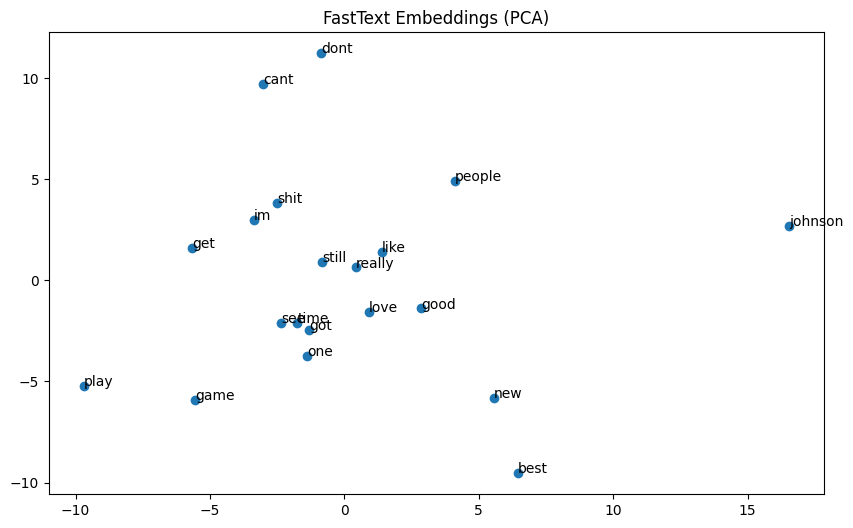

In [21]:
# Get word vectors
fasttext_vectors = fasttext_model.wv

# Example: Get vector for a specific word
vector = fasttext_vectors['game']
print(f"FastText Vector for 'game': {vector}")

# Visualize word embeddings (e.g., using PCA)
vectors = [fasttext_vectors[word] for word in words]
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title('FastText Embeddings (PCA)')
plt.show()